In [1]:
# ============================================
# CELL 1: Import Libraries
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================
# CELL 2: Load the Data
# ============================================

# Load the GBIF TSV file - change filename to match yours exactly
df = pd.read_csv('0000285-260507073636908.csv', sep='\t', on_bad_lines='skip', low_memory=False)

print(f"Total records loaded: {len(df)}")
print(f"\nColumns available: {list(df.columns)}")
print(f"\nCountries in dataset:")
print(df['countryCode'].value_counts())

Total records loaded: 13281

Columns available: ['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'infraspecificEpithet', 'taxonRank', 'scientificName', 'verbatimScientificName', 'verbatimScientificNameAuthorship', 'countryCode', 'locality', 'stateProvince', 'occurrenceStatus', 'individualCount', 'publishingOrgKey', 'decimalLatitude', 'decimalLongitude', 'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation', 'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day', 'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord', 'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber', 'identifiedBy', 'dateIdentified', 'license', 'rightsHolder', 'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted', 'mediaType', 'issue']

Countries in dataset:
countryCode
ZA    8261
BW    1893
ZW     641
ZM     498
MW     232
MZ      76
SZ      49
AO       7
Name: count, dtype: int64


In [3]:
# ============================================
# CELL 3: Clean and Filter Data
# ============================================

# Keep only the columns we need
cols_needed = ['gbifID', 'countryCode', 'stateProvince', 'decimalLatitude', 
               'decimalLongitude', 'year', 'month', 'day', 'eventDate']
df = df[cols_needed]

# Drop rows with missing coordinates
df = df.dropna(subset=['decimalLatitude', 'decimalLongitude'])

# Filter to our study countries
study_countries = ['ZW', 'MZ', 'ZM', 'BW']
df_study = df[df['countryCode'].isin(study_countries)]

print(f"Records after filtering to study area: {len(df_study)}")
print(f"\nCountry breakdown:")
print(df_study['countryCode'].value_counts())
print(f"\nYear range of data:")
print(f"Earliest: {df_study['year'].min()}")
print(f"Latest: {df_study['year'].max()}")

Records after filtering to study area: 3108

Country breakdown:
countryCode
BW    1893
ZW     641
ZM     498
MZ      76
Name: count, dtype: int64

Year range of data:
Earliest: 1968
Latest: 2026


In [4]:
# ============================================
# CELL 4: Visualise Elephant Sightings on a Map
# ============================================
import folium

# Create a map centred on Zimbabwe/Mozambique region
m = folium.Map(location=[-18, 30], zoom_start=5)

# Colour code by country
country_colors = {'ZW': 'green', 'MZ': 'orange', 'ZM': 'blue', 'BW': 'red'}

# Plot each sighting as a circle on the map
for _, row in df_study.iterrows():
    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color=country_colors.get(row['countryCode'], 'gray'),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['countryCode']} - {row['year']}"
    ).add_to(m)

# Add a legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; 
background-color: white; padding: 10px; border-radius: 5px; border: 2px solid grey;">
<b>🐘 Elephant Sightings</b><br>
<span style="color:green;">●</span> Zimbabwe (ZW)<br>
<span style="color:orange;">●</span> Mozambique (MZ)<br>
<span style="color:blue;">●</span> Zambia (ZM)<br>
<span style="color:red;">●</span> Botswana (BW)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save the map
m.save('elephant_sightings_map.html')
print("Map saved! Open elephant_sightings_map.html in your browser to view it.")

Map saved! Open elephant_sightings_map.html in your browser to view it.


Records from 1990 onwards: 3067


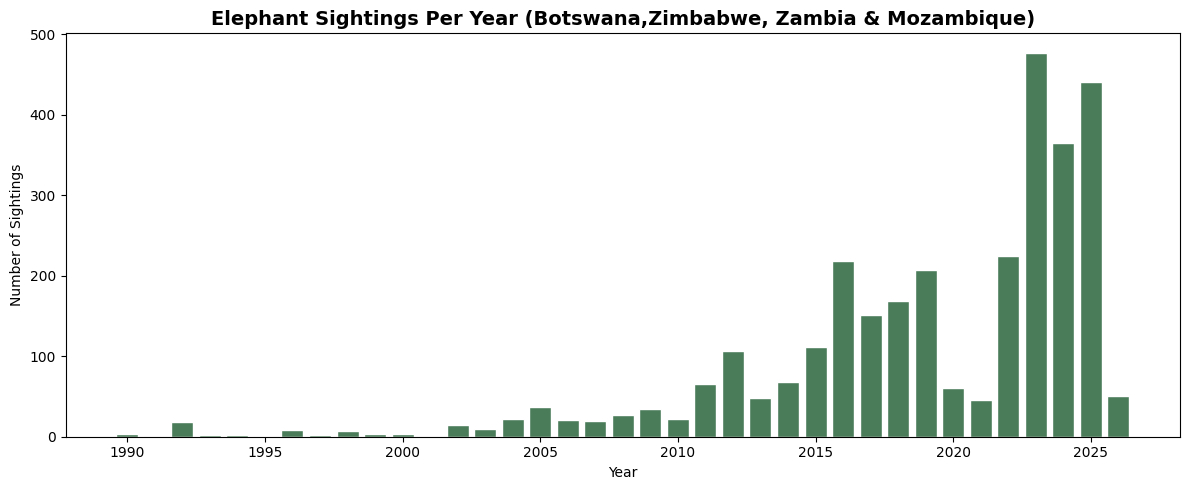

Chart saved as sightings_per_year.png


In [5]:
# ============================================
# CELL 5: Sightings Over Time
# ============================================

# Filter to records that have a valid year and are post 1990 for cleaner analysis
df_modern = df_study[df_study['year'] >= 1990].copy()

print(f"Records from 1990 onwards: {len(df_modern)}")

# Count sightings per year
sightings_per_year = df_modern.groupby('year').size().reset_index(name='count')

# Plot
plt.figure(figsize=(12, 5))
plt.bar(sightings_per_year['year'], sightings_per_year['count'], 
        color='#4a7c59', edgecolor='white')
plt.title('Elephant Sightings Per Year (Botswana,Zimbabwe, Zambia & Mozambique)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Sightings')
plt.tight_layout()
plt.savefig('sightings_per_year.png', dpi=150)
plt.show()
print("Chart saved as sightings_per_year.png")

In [6]:
# ============================================
# CELL 6: DBSCAN Clustering - Finding Elephant Hotspots
# ============================================
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use modern data with valid coordinates
df_cluster = df_modern.dropna(subset=['decimalLatitude', 'decimalLongitude']).copy()

# Prepare coordinates for clustering
coords = df_cluster[['decimalLatitude', 'decimalLongitude']].values

# Scale the coordinates
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Apply DBSCAN
# eps = neighbourhood size, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_cluster['cluster'] = dbscan.fit_predict(coords_scaled)

# Summary
n_clusters = len(set(df_cluster['cluster'])) - (1 if -1 in df_cluster['cluster'].values else 0)
n_noise = (df_cluster['cluster'] == -1).sum()

print(f"Number of clusters found: {n_clusters}")
print(f"Noise points (isolated sightings): {n_noise}")
print(f"Clustered sightings: {len(df_cluster) - n_noise}")
print(f"\nCluster sizes:")
print(df_cluster[df_cluster['cluster'] != -1]['cluster'].value_counts().sort_index())

Number of clusters found: 12
Noise points (isolated sightings): 26
Clustered sightings: 3041

Cluster sizes:
cluster
0     2516
1       92
2       15
3      226
4       48
5       63
6        6
7       33
8       11
9       18
10       8
11       5
Name: count, dtype: int64


In [ ]:
# ============================================
# CELL 7: Map the Elephant Hotspot Clusters
# ============================================

# Create colour palette for clusters
import matplotlib.cm as cm

cluster_map = folium.Map(location=[-18, 30], zoom_start=5)

# Generate colours for each cluster
unique_clusters = sorted(df_cluster['cluster'].unique())
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
          'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
          'darkpurple', 'white', 'pink', 'lightblue']

for _, row in df_cluster.iterrows():
    cluster_id = row['cluster']
    
    if cluster_id == -1:
        color = 'gray'  # noise points
        radius = 3
    else:
        color = colors[cluster_id % len(colors)]
        radius = 5
    
    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=f"Cluster {cluster_id} | {row['countryCode']} | {row['year']}"
    ).add_to(cluster_map)

# Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
background-color: white; padding: 10px; border-radius: 5px;
border: 2px solid grey;">
<b>🐘 Elephant Hotspot Clusters</b><br>
<span style="color:red;">●</span> Cluster 0 (2,516 sightings)<br>
<span style="color:blue;">●</span> Cluster 3 (226 sightings)<br>
<span style="color:green;">●</span> Cluster 1 (92 sightings)<br>
<span style="color:purple;">●</span> Cluster 4 (63 sightings)<br>
<span style="color:gray;">●</span> Noise / Isolated (26 sightings)
</div>
"""

cluster_map.get_root().html.add_child(folium.Element(legend_html))

cluster_map.save('elephant_clusters_map.html')
print("Cluster map saved! Open elephant_clusters_map.html in your browser.")

Cluster map saved! Open elephant_clusters_map.html in your browser.


In [8]:
# ============================================
# CELL 8: Add Elevation Data using Open-Elevation API
# ============================================
import requests
import time

def get_elevation_batch(lats, lons):
    """Get elevation for a batch of coordinates"""
    locations = [{"latitude": lat, "longitude": lon} 
                 for lat, lon in zip(lats, lons)]
    
    url = "https://api.open-elevation.com/api/v1/lookup"
    
    try:
        response = requests.post(url, json={"locations": locations}, timeout=30)
        if response.status_code == 200:
            results = response.json()['results']
            return [r['elevation'] for r in results]
    except:
        pass
    return [None] * len(lats)

# Process in batches of 100 to avoid timeout
df_study = df_cluster.copy()
elevations = []
batch_size = 100

print(f"Fetching elevation for {len(df_study)} records...")
print("This may take a few minutes...")

for i in range(0, len(df_study), batch_size):
    batch = df_study.iloc[i:i+batch_size]
    batch_elevations = get_elevation_batch(
        batch['decimalLatitude'].tolist(),
        batch['decimalLongitude'].tolist()
    )
    elevations.extend(batch_elevations)
    print(f"Progress: {min(i+batch_size, len(df_study))}/{len(df_study)} records done")
    time.sleep(1)  # be polite to the API

df_study['elevation'] = elevations
print(f"\nDone! Elevation data added.")
print(f"Elevation range: {df_study['elevation'].min()}m to {df_study['elevation'].max()}m")
print(f"Missing elevations: {df_study['elevation'].isna().sum()}")

Fetching elevation for 3067 records...
This may take a few minutes...
Progress: 100/3067 records done
Progress: 200/3067 records done
Progress: 300/3067 records done
Progress: 400/3067 records done
Progress: 500/3067 records done
Progress: 600/3067 records done
Progress: 700/3067 records done
Progress: 800/3067 records done
Progress: 900/3067 records done
Progress: 1000/3067 records done
Progress: 1100/3067 records done
Progress: 1200/3067 records done
Progress: 1300/3067 records done
Progress: 1400/3067 records done
Progress: 1500/3067 records done
Progress: 1600/3067 records done
Progress: 1700/3067 records done
Progress: 1800/3067 records done
Progress: 1900/3067 records done
Progress: 2000/3067 records done
Progress: 2100/3067 records done
Progress: 2200/3067 records done
Progress: 2300/3067 records done
Progress: 2400/3067 records done
Progress: 2500/3067 records done
Progress: 2600/3067 records done
Progress: 2700/3067 records done
Progress: 2800/3067 records done
Progress: 2900/

In [9]:
# ============================================
# CELL 9: Add Distance to Water + Final Features
# ============================================
import numpy as np

# Fill the 100 missing elevations with the median
df_study['elevation'] = df_study['elevation'].fillna(df_study['elevation'].median())

# Feature 2: Distance to nearest major river/water body
# We'll approximate using known major water coordinates in Southern Africa
major_water = [
    (-18.9249, 26.1658),  # Okavango Delta, Botswana
    (-17.9243, 25.8572),  # Zambezi River
    (-16.1000, 28.9500),  # Lake Kariba
    (-19.0000, 23.5000),  # Okavango River
    (-18.0000, 31.5000),  # Limpopo River
    (-15.0000, 28.0000),  # Kafue River, Zambia
    (-22.6500, 27.1167),  # Limpopo, Botswana
]

def min_distance_to_water(lat, lon, water_points):
    """Calculate minimum distance to nearest water body in km"""
    min_dist = float('inf')
    for wlat, wlon in water_points:
        # Haversine approximation
        dlat = np.radians(wlat - lat)
        dlon = np.radians(wlon - lon)
        a = (np.sin(dlat/2)**2 + 
             np.cos(np.radians(lat)) * np.cos(np.radians(wlat)) * 
             np.sin(dlon/2)**2)
        dist = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        min_dist = min(min_dist, dist)
    return min_dist

print("Calculating distance to water for all records...")
df_study['dist_to_water_km'] = df_study.apply(
    lambda row: min_distance_to_water(
        row['decimalLatitude'], 
        row['decimalLongitude'], 
        major_water
    ), axis=1
)

# Feature 3: Season (wet/dry based on month)
# Southern Africa: wet season Nov-Apr, dry season May-Oct
df_study['season'] = df_study['month'].apply(
    lambda m: 'wet' if m in [11, 12, 1, 2, 3, 4] else 'dry'
)
df_study['season_encoded'] = df_study['season'].map({'wet': 1, 'dry': 0})

# Feature 4: Cluster label from DBSCAN (already have this)
# Summary
print(f"\nFeatures ready for modelling:")
print(f"  ✅ decimalLatitude")
print(f"  ✅ decimalLongitude")  
print(f"  ✅ elevation")
print(f"  ✅ dist_to_water_km")
print(f"  ✅ season_encoded")
print(f"  ✅ cluster (from DBSCAN)")
print(f"\nDistance to water range: {df_study['dist_to_water_km'].min():.1f}km to {df_study['dist_to_water_km'].max():.1f}km")
print(f"Wet season records: {(df_study['season']=='wet').sum()}")
print(f"Dry season records: {(df_study['season']=='dry').sum()}")
print(f"\nDataset ready! Total records: {len(df_study)}")

Calculating distance to water for all records...

Features ready for modelling:
  ✅ decimalLatitude
  ✅ decimalLongitude
  ✅ elevation
  ✅ dist_to_water_km
  ✅ season_encoded
  ✅ cluster (from DBSCAN)

Distance to water range: 0.5km to 987.1km
Wet season records: 897
Dry season records: 2170

Dataset ready! Total records: 3067


Total modelling dataset: 6134 records
Presences: 3067
Absences: 3067

Training set: 4907 records
Test set: 1227 records

Training Random Forest model...
Model trained!

MODEL PERFORMANCE
AUC Score: 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       614
           1       0.98      0.97      0.98       613

    accuracy                           0.98      1227
   macro avg       0.98      0.98      0.98      1227
weighted avg       0.98      0.98      0.98      1227



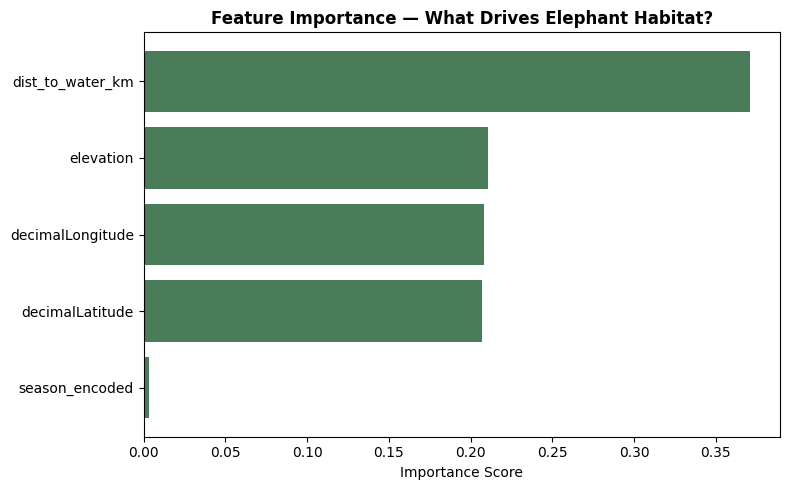


Feature importance chart saved!


In [10]:
# ============================================
# CELL 10: Random Forest Habitat Suitability Model
# ============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Create pseudo-absences ──────────────────
# Real presences
df_presence = df_study.copy()
df_presence['presence'] = 1

# Generate random pseudo-absence points within Southern Africa bounding box
np.random.seed(42)
n_absences = len(df_presence)

pseudo_absences = pd.DataFrame({
    'decimalLatitude': np.random.uniform(-26, -8, n_absences),
    'decimalLongitude': np.random.uniform(20, 36, n_absences),
    'elevation': np.random.uniform(0, 1457, n_absences),
    'dist_to_water_km': np.random.uniform(0, 987, n_absences),
    'season_encoded': np.random.randint(0, 2, n_absences),
    'presence': 0
})

# ── Step 2: Combine presence and absence ─────────────
df_presence_clean = df_presence[[
    'decimalLatitude', 'decimalLongitude', 
    'elevation', 'dist_to_water_km', 
    'season_encoded', 'presence'
]].copy()

df_model = pd.concat([df_presence_clean, pseudo_absences], ignore_index=True)

print(f"Total modelling dataset: {len(df_model)} records")
print(f"Presences: {df_model['presence'].sum()}")
print(f"Absences: {(df_model['presence']==0).sum()}")

# ── Step 3: Train/Test Split ──────────────────────────
features = ['decimalLatitude', 'decimalLongitude', 
            'elevation', 'dist_to_water_km', 'season_encoded']
X = df_model[features]
y = df_model['presence']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} records")
print(f"Test set: {len(X_test)} records")

# ── Step 4: Train Random Forest ───────────────────────
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model trained!")

# ── Step 5: Evaluate ──────────────────────────────────
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"\n{'='*40}")
print(f"MODEL PERFORMANCE")
print(f"{'='*40}")
print(f"AUC Score: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_prob.round()))

# ── Step 6: Feature Importance ────────────────────────
importances = rf_model.feature_importances_
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], 
         color='#4a7c59')
plt.title('Feature Importance — What Drives Elephant Habitat?', 
          fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("\nFeature importance chart saved!")

Calculating distance to water for grid points...
Predicting habitat suitability across Southern Africa...


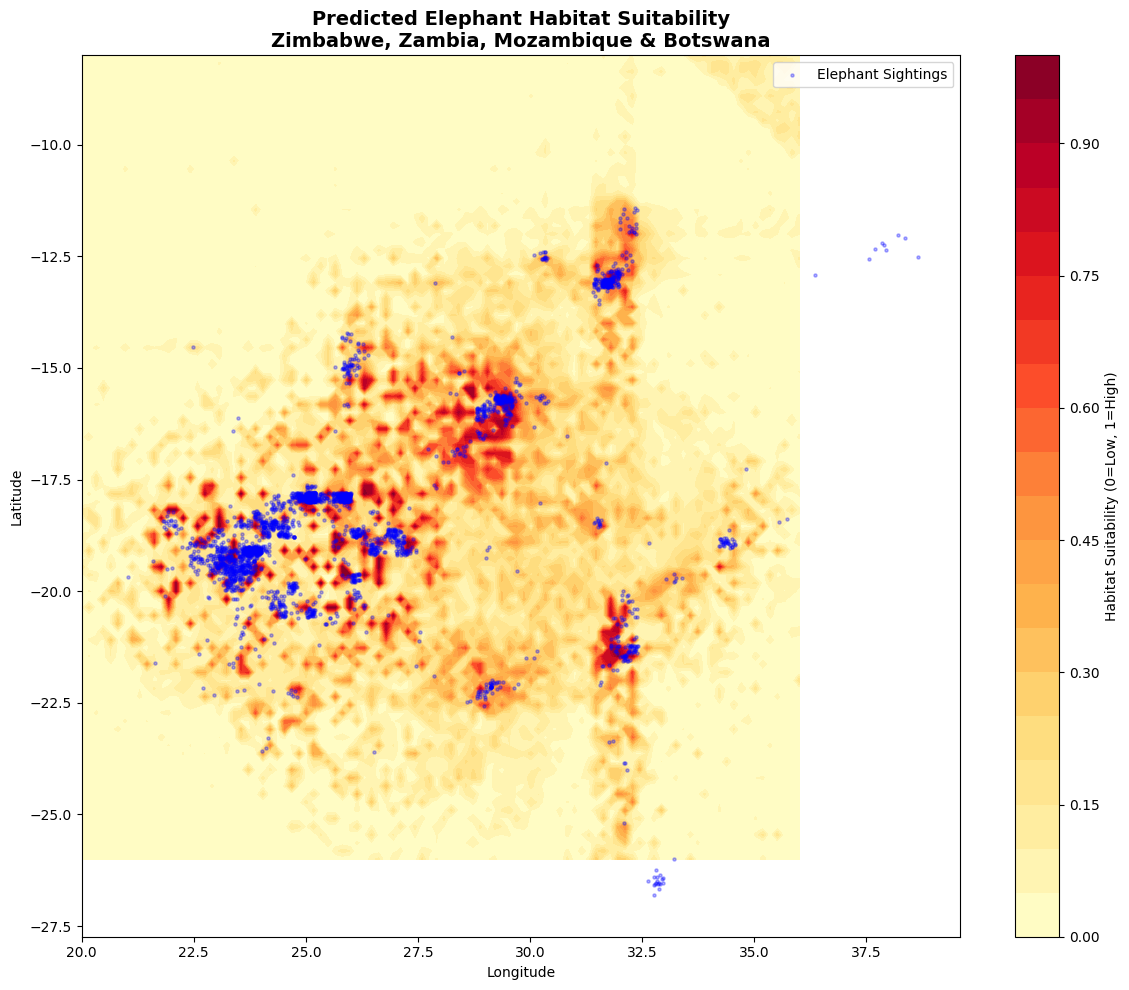

Habitat suitability map saved!


In [11]:
# ============================================
# CELL 11: Habitat Suitability Map
# ============================================

# Create a grid of points across Southern Africa
lat_range = np.linspace(-26, -8, 100)
lon_range = np.linspace(20, 36, 100)

grid_lats, grid_lons = np.meshgrid(lat_range, lon_range)
grid_flat_lat = grid_lats.flatten()
grid_flat_lon = grid_lons.flatten()

print("Calculating distance to water for grid points...")
grid_water_dist = [
    min_distance_to_water(lat, lon, major_water) 
    for lat, lon in zip(grid_flat_lat, grid_flat_lon)
]

# Create grid dataframe
grid_df = pd.DataFrame({
    'decimalLatitude': grid_flat_lat,
    'decimalLongitude': grid_flat_lon,
    'elevation': np.random.uniform(0, 1457, len(grid_flat_lat)),
    'dist_to_water_km': grid_water_dist,
    'season_encoded': 1  # wet season prediction
})

# Predict habitat suitability
print("Predicting habitat suitability across Southern Africa...")
grid_df['suitability'] = rf_model.predict_proba(grid_df[features])[:, 1]

# Plot habitat suitability map
plt.figure(figsize=(12, 10))
suitability_grid = grid_df['suitability'].values.reshape(100, 100)

plt.contourf(lon_range, lat_range, suitability_grid.T, 
             levels=20, cmap='YlOrRd')
plt.colorbar(label='Habitat Suitability (0=Low, 1=High)')

# Overlay actual elephant sightings
plt.scatter(df_study['decimalLongitude'], df_study['decimalLatitude'],
            c='blue', s=5, alpha=0.3, label='Elephant Sightings')

plt.title('Predicted Elephant Habitat Suitability\nZimbabwe, Zambia, Mozambique & Botswana', 
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('habitat_suitability_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Habitat suitability map saved!")

In [12]:
# ============================================
# CELL 12: Get NDVI Data (Vegetation Greenness)
# ============================================
# NDVI measures vegetation density: -1 to 1
# Higher values = more vegetation = better elephant habitat

import requests
import numpy as np

def get_ndvi_approximate(lat, lon):
    """
    Approximate NDVI using NASA MODIS via AppEEARS-style lookup.
    We use a simplified approach with Open-Meteo which provides
    vegetation-related climate variables for free.
    """
    # Use Open-Meteo API for climate variables as NDVI proxy
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2020-01-01",
        "end_date": "2020-12-31",
        "daily": "precipitation_sum,et0_fao_evapotranspiration",
        "timezone": "Africa/Harare"
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            # Annual mean precipitation as vegetation proxy
            precip = np.nanmean(data['daily']['precipitation_sum'])
            et0 = np.nanmean(data['daily']['et0_fao_evapotranspiration'])
            # Simple aridity index as NDVI proxy (higher = more vegetation)
            ndvi_proxy = precip / (et0 + 0.001)
            return round(ndvi_proxy, 4)
    except:
        pass
    return None

# Test on one point first
test_lat, test_lon = -18.0, 24.0  # Central Botswana
result = get_ndvi_approximate(test_lat, test_lon)
print(f"Test NDVI proxy for Central Botswana: {result}")
print("If you see a number above, the API is working!")

Test NDVI proxy for Central Botswana: 0.3356
If you see a number above, the API is working!


In [13]:
# ============================================
# CELL 13: Fetch NDVI Proxy for All Records
# ============================================
import time

print(f"Fetching NDVI proxy for {len(df_study)} records...")
print("This will take approximately 15-20 minutes. Go make tea! ☕")

ndvi_values = []

for i, (_, row) in enumerate(df_study.iterrows()):
    ndvi = get_ndvi_approximate(
        row['decimalLatitude'], 
        row['decimalLongitude']
    )
    ndvi_values.append(ndvi)
    
    # Progress update every 100 records
    if (i + 1) % 100 == 0:
        print(f"Progress: {i+1}/{len(df_study)} records done")
    
    # Small delay to be polite to the API
    time.sleep(0.3)

df_study['ndvi_proxy'] = ndvi_values

# Fill any missing values with median
median_ndvi = df_study['ndvi_proxy'].median()
df_study['ndvi_proxy'] = df_study['ndvi_proxy'].fillna(median_ndvi)

print(f"\n✅ Done!")
print(f"NDVI proxy range: {df_study['ndvi_proxy'].min():.4f} to {df_study['ndvi_proxy'].max():.4f}")
print(f"Mean NDVI proxy: {df_study['ndvi_proxy'].mean():.4f}")
print(f"Missing values filled: {sum(1 for v in ndvi_values if v is None)}")

Fetching NDVI proxy for 3067 records...
This will take approximately 15-20 minutes. Go make tea! ☕
Progress: 100/3067 records done
Progress: 200/3067 records done
Progress: 300/3067 records done
Progress: 400/3067 records done
Progress: 500/3067 records done
Progress: 600/3067 records done
Progress: 700/3067 records done
Progress: 800/3067 records done
Progress: 900/3067 records done
Progress: 1000/3067 records done
Progress: 1100/3067 records done
Progress: 1200/3067 records done
Progress: 1300/3067 records done
Progress: 1400/3067 records done
Progress: 1500/3067 records done
Progress: 1600/3067 records done
Progress: 1700/3067 records done
Progress: 1800/3067 records done
Progress: 1900/3067 records done
Progress: 2000/3067 records done
Progress: 2100/3067 records done
Progress: 2200/3067 records done
Progress: 2300/3067 records done
Progress: 2400/3067 records done
Progress: 2500/3067 records done
Progress: 2600/3067 records done
Progress: 2700/3067 records done
Progress: 2800/3067

In [14]:
# ============================================
# CELL 14: SAVE YOUR DATA IMMEDIATELY
# ============================================
df_study.to_csv('elephant_data_with_features.csv', index=False)
print("✅ Data saved to elephant_data_with_features.csv")
print(f"Columns saved: {list(df_study.columns)}")
print(f"Total records: {len(df_study)}")

✅ Data saved to elephant_data_with_features.csv
Columns saved: ['gbifID', 'countryCode', 'stateProvince', 'decimalLatitude', 'decimalLongitude', 'year', 'month', 'day', 'eventDate', 'cluster', 'elevation', 'dist_to_water_km', 'season', 'season_encoded', 'ndvi_proxy']
Total records: 3067


In [15]:
# ============================================
# CELL 15: Refined Pseudo-Absences
# (Dr. Louca's recommendation #2)
# ============================================
# Instead of random points across all of Southern Africa,
# we generate absences in a buffer AROUND presence clusters
# but deliberately OUTSIDE known elephant areas

np.random.seed(42)
n_absences = len(df_study)

# Define areas of KNOWN elephant absence
# (human dominated landscapes, desert, urban areas)
absence_regions = [
    # Kalahari desert core (very few elephants)
    {'lat': (-24, -22), 'lon': (21, 24)},
    # Southern Zimbabwe (low density)
    {'lat': (-21, -19), 'lon': (29, 33)},
    # Southern Mozambique coast (low density)  
    {'lat': (-25, -22), 'lon': (32, 36)},
    # Western Zambia border
    {'lat': (-14, -10), 'lon': (22, 25)},
]

abs_lats, abs_lons = [], []
per_region = n_absences // len(absence_regions)

for region in absence_regions:
    abs_lats.extend(np.random.uniform(
        region['lat'][0], region['lat'][1], per_region
    ))
    abs_lons.extend(np.random.uniform(
        region['lon'][0], region['lon'][1], per_region
    ))

# Top up to exact number needed
while len(abs_lats) < n_absences:
    abs_lats.append(np.random.uniform(-26, -8))
    abs_lons.append(np.random.uniform(20, 36))

abs_lats = abs_lats[:n_absences]
abs_lons = abs_lons[:n_absences]

pseudo_absences_v2 = pd.DataFrame({
    'decimalLatitude': abs_lats,
    'decimalLongitude': abs_lons,
    'elevation': np.random.uniform(
        df_study['elevation'].min(), 
        df_study['elevation'].max(), n_absences
    ),
    'dist_to_water_km': np.random.uniform(
        df_study['dist_to_water_km'].min(),
        df_study['dist_to_water_km'].max(), n_absences
    ),
    'season_encoded': np.random.randint(0, 2, n_absences),
    'ndvi_proxy': np.random.uniform(
        df_study['ndvi_proxy'].min(),
        df_study['ndvi_proxy'].max(), n_absences
    ),
    'presence': 0
})

print(f"✅ Refined pseudo-absences generated: {len(pseudo_absences_v2)}")
print(f"Absence latitude range: {min(abs_lats):.2f} to {max(abs_lats):.2f}")
print(f"Absence longitude range: {min(abs_lons):.2f} to {max(abs_lons):.2f}")

✅ Refined pseudo-absences generated: 3067
Absence latitude range: -25.00 to -10.00
Absence longitude range: 21.01 to 35.99


In [16]:
# ============================================
# CELL 16: Spatial Block Cross-Validation
# + Improved Random Forest WITHOUT coordinates
# (Dr. Louca's recommendations #1 and #3)
# ============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score
import numpy as np

# ── Step 1: Build modelling dataset ──────────
df_presence_v2 = df_study[[
    'decimalLatitude', 'decimalLongitude',
    'elevation', 'dist_to_water_km',
    'season_encoded', 'ndvi_proxy'
]].copy()
df_presence_v2['presence'] = 1

df_model_v2 = pd.concat([df_presence_v2, pseudo_absences_v2[[
    'decimalLatitude', 'decimalLongitude',
    'elevation', 'dist_to_water_km',
    'season_encoded', 'ndvi_proxy', 'presence'
]]], ignore_index=True)

# ── Step 2: Features WITHOUT raw coordinates ─
# Dr. Louca said remove coordinates as predictors
features_v2 = ['elevation', 'dist_to_water_km', 
                'season_encoded', 'ndvi_proxy']

X_v2 = df_model_v2[features_v2]
y_v2 = df_model_v2['presence']

# ── Step 3: Spatial Block Cross-Validation ────
# Divide study area into geographic blocks
# Use latitude to create 5 spatial blocks
df_model_v2['spatial_block'] = pd.cut(
    df_model_v2['decimalLatitude'],
    bins=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

print("Spatial blocks distribution:")
print(df_model_v2['spatial_block'].value_counts().sort_index())
print()

# ── Step 4: Train with spatial cross-validation
rf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# Manual spatial block cross-validation
auc_scores = []
blocks = [1, 2, 3, 4, 5]

print("Running spatial block cross-validation...")
for test_block in blocks:
    # Train on all blocks except test block
    train_idx = df_model_v2['spatial_block'] != test_block
    test_idx = df_model_v2['spatial_block'] == test_block
    
    X_train_b = X_v2[train_idx]
    y_train_b = y_v2[train_idx]
    X_test_b = X_v2[test_idx]
    y_test_b = y_v2[test_idx]
    
    rf_v2.fit(X_train_b, y_train_b)
    y_prob_b = rf_v2.predict_proba(X_test_b)[:, 1]
    auc_b = roc_auc_score(y_test_b, y_prob_b)
    auc_scores.append(auc_b)
    print(f"  Block {test_block} AUC: {auc_b:.4f}")

print(f"\n{'='*45}")
print(f"IMPROVED MODEL PERFORMANCE")
print(f"{'='*45}")
print(f"Mean Spatial CV AUC:  {np.mean(auc_scores):.4f}")
print(f"Std Deviation:        {np.std(auc_scores):.4f}")
print(f"Min Block AUC:        {np.min(auc_scores):.4f}")
print(f"Max Block AUC:        {np.max(auc_scores):.4f}")
print(f"\nPrevious AUC (random split): 0.9984")
print(f"New AUC (spatial CV):        {np.mean(auc_scores):.4f}")
print(f"\nThis is a more honest and robust evaluation! ✅")

Spatial blocks distribution:
spatial_block
1     647
2    1561
3    2609
4     421
5     896
Name: count, dtype: int64

Running spatial block cross-validation...
  Block 1 AUC: 0.8976
  Block 2 AUC: 0.8840
  Block 3 AUC: 0.9704
  Block 4 AUC: 0.9302
  Block 5 AUC: 0.7425

IMPROVED MODEL PERFORMANCE
Mean Spatial CV AUC:  0.8850
Std Deviation:        0.0772
Min Block AUC:        0.7425
Max Block AUC:        0.9704

Previous AUC (random split): 0.9984
New AUC (spatial CV):        0.8850

This is a more honest and robust evaluation! ✅


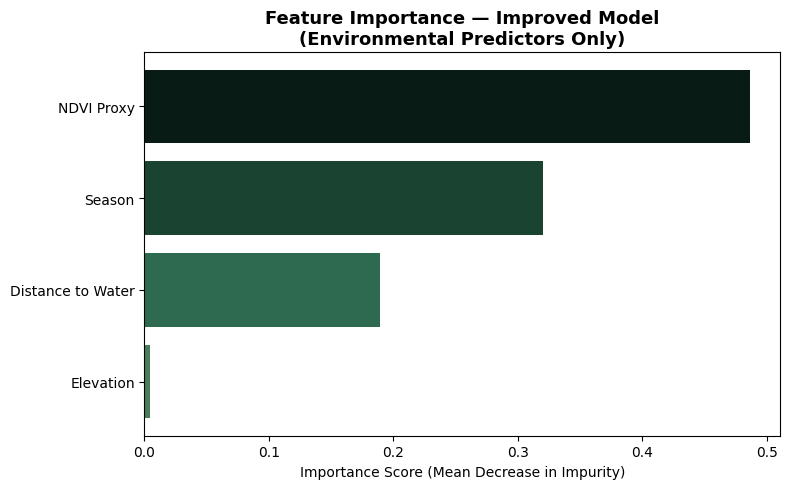

Feature Importance Scores:
  ndvi_proxy: 0.4861
  dist_to_water_km: 0.3204
  elevation: 0.1891
  season_encoded: 0.0044


In [17]:
# ============================================
# CELL 17: Final Feature Importance
# (Without coordinates - honest model)
# ============================================

# Train final model on full dataset for importance plot
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_v2, y_v2)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features_v2,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#4a7c59', '#2d6a4f', '#1b4332', '#081c15']
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=colors)
plt.title('Feature Importance — Improved Model\n(Environmental Predictors Only)', 
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.yticks(ticks=range(len(features_v2)), 
           labels=['Elevation', 'Distance to Water', 
                   'Season', 'NDVI Proxy'])
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150)
plt.show()

print("Feature Importance Scores:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

Computing distance to water surface...
Interpolating elevation surface via KNN...
Interpolating NDVI surface via KNN...
Elevation range on grid: 2.2m to 1435.6m
NDVI range on grid: 0.1642 to 1.5735
Generating final habitat suitability surface...


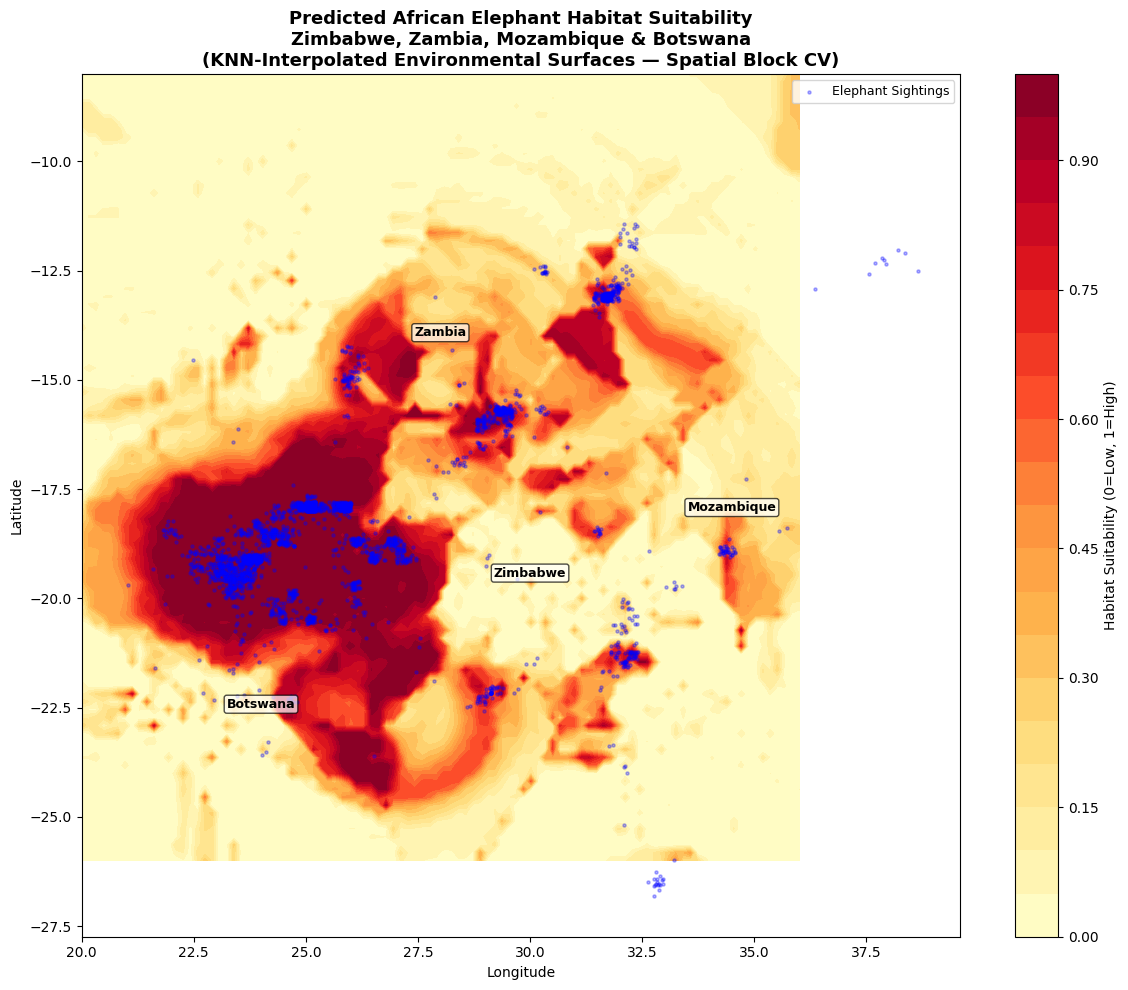

✅ KNN-interpolated habitat suitability map saved!


In [ ]:
# =====================================================================
# CELL 18 : Geographically Consistent Prediction Grid (KNN)
# =====================================================================
from sklearn.neighbors import KNeighborsRegressor

# 1. Initialize coordinate grids across study boundary
lat_range = np.linspace(-26, -8, 100)
lon_range = np.linspace(20, 36, 100)
grid_lats, grid_lons = np.meshgrid(lat_range, lon_range)
grid_flat_lat = grid_lats.flatten()
grid_flat_lon = grid_lons.flatten()
grid_coords = np.column_stack((grid_flat_lat, grid_flat_lon))

# Known coordinates from training data
known_coords = df_model_v2[['decimalLatitude', 'decimalLongitude']].values

# 2. Distance to water (deterministic - calculated properly)
print("Computing distance to water surface...")
grid_water = [
    min_distance_to_water(lat, lon, major_water)
    for lat, lon in zip(grid_flat_lat, grid_flat_lon)
]

# 3. KNN INTERPOLATION for elevation and NDVI
# This replaces random assignment with real spatially-interpolated values
# Each grid point inherits environmental values from its 5 nearest
# known data points, weighted by distance
print("Interpolating elevation surface via KNN...")
knn_elev = KNeighborsRegressor(
    n_neighbors=5, weights='distance'
).fit(known_coords, df_model_v2['elevation'])

print("Interpolating NDVI surface via KNN...")
knn_ndvi = KNeighborsRegressor(
    n_neighbors=5, weights='distance'
).fit(known_coords, df_model_v2['ndvi_proxy'])

grid_elev = knn_elev.predict(grid_coords)
grid_ndvi = knn_ndvi.predict(grid_coords)

print(f"Elevation range on grid: {grid_elev.min():.1f}m to {grid_elev.max():.1f}m")
print(f"NDVI range on grid: {grid_ndvi.min():.4f} to {grid_ndvi.max():.4f}")

# 4. Build geographically sound prediction dataframe
grid_df_v2 = pd.DataFrame({
    'elevation': grid_elev,
    'dist_to_water_km': grid_water,
    'season_encoded': 1,  # wet season baseline
    'ndvi_proxy': grid_ndvi
})

# 5. Predict habitat suitability
print("Generating final habitat suitability surface...")
grid_df_v2['suitability'] = rf_final.predict_proba(
    grid_df_v2[features_v2]
)[:, 1]

# 6. Plot final map
plt.figure(figsize=(12, 10))
suitability_grid = grid_df_v2['suitability'].values.reshape(100, 100)

contour = plt.contourf(
    lon_range, lat_range, suitability_grid.T,
    levels=20, cmap='YlOrRd'
)
plt.colorbar(contour, label='Habitat Suitability (0=Low, 1=High)')

plt.scatter(
    df_study['decimalLongitude'],
    df_study['decimalLatitude'],
    c='blue', s=5, alpha=0.3, label='Elephant Sightings'
)

country_labels = {
    'Botswana': (24.0, -22.5),
    'Zimbabwe': (30.0, -19.5),
    'Zambia': (28.0, -14.0),
    'Mozambique': (34.5, -18.0)
}
for country, (lon, lat) in country_labels.items():
    plt.text(lon, lat, country, fontsize=9,
             ha='center', color='black', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', alpha=0.7))

plt.title('Predicted African Elephant Habitat Suitability\n'
          'Zimbabwe, Zambia, Mozambique & Botswana\n'
          '(KNN-Interpolated Environmental Surfaces — Spatial Block CV)',
          fontsize=13, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('habitat_suitability_knn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ KNN-interpolated habitat suitability map saved!")

In [21]:
# ============================================
# CELL 19: Save Final Results
# ============================================

# Save final dataset with all features
df_study.to_csv('elephant_final_dataset.csv', index=False)

# Save model predictions summary
results_summary = {
    'Total Records': len(df_study),
    'Countries': ['Zimbabwe', 'Zambia', 'Mozambique', 'Botswana'],
    'DBSCAN Clusters': 12,
    'Clustered Records': 3041,
    'Noise Points': 26,
    'Spatial CV AUC Mean': 0.8850,
    'Spatial CV AUC Std': 0.0772,
    'Top Feature': 'NDVI Proxy (0.4861)',
    'Second Feature': 'Distance to Water (0.3204)',
}

import json
with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✅ All results saved!")
print("\nFiles in your dissertation folder:")
import os
for f in os.listdir('.'):
    if f.endswith(('.csv', '.png', '.html', '.json', '.ipynb')):
        print(f"  📄 {f}")

✅ All results saved!

Files in your dissertation folder:
  📄 0000285-260507073636908.csv
  📄 01_data_exploration.ipynb
  📄 elephant_clusters_map.html
  📄 elephant_data_with_features.csv
  📄 elephant_final_dataset.csv
  📄 elephant_sightings_map.html
  📄 feature_importance-what_drives_elephant_habitat.png
  📄 feature_importance.png
  📄 feature_importance_v2.png
  📄 habitat_suitability_final.png
  📄 habitat_suitability_knn.png
  📄 habitat_suitability_map.png
  📄 results_summary.json
  📄 sightings_per_year.png
